# Germany pair-filter strategy runner

Notebook client pour lancer le meilleur resultat Germany actuel : **pair_filter_corr_abs_le_0p75**.

Definition du filtre : conserver uniquement les paires avec `abs(6m_corr) <= 0.75`, donc exclure les paires `high_corr` identifiees comme destructrices dans la phase 2 Germany.

Le notebook ne retune rien, ne modifie pas le moteur core, et reutilise les helpers de recherche existants.

In [1]:
from pathlib import Path
import json
import logging
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'scripts' / 'run_germany_phase2_campaign.py').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root from the current notebook directory.')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option('display.max_columns', 180)
pd.set_option('display.width', 240)
plt.style.use('seaborn-v0_8-whitegrid')

logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
print(f'Project root: {PROJECT_ROOT}')

try:
    import plotly.io as pio
    pio.renderers.default = 'notebook_connected'
except Exception:
    pass


Project root: D:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal


In [2]:
from scripts.run_sweden_filter_ablation_campaign import FilterThresholds
from utils.country_research_pipeline import (
    ASSET_REGISTRY_PATH,
    BASE_DATA_PATH,
    DEFAULT_ABS_Z_THRESHOLD,
    DEFAULT_ZSPEED_EWMA_THRESHOLD,
    build_concentration,
    build_country_assets,
    build_trade_level,
    config_to_dict,
    enrich_run,
    load_or_build_country_scans,
    load_price_panel,
    compute_market_regime_features,
    run_variant,
    select_country_reference,
)
from utils.edge_decomposition import (
    REGIME_RULES_DESCRIPTION,
    build_pair_level_summary,
    summarize_edge_by_segment,
)
from utils.germany_phase2 import (
    GERMANY_BETA_THRESHOLD,
    VariantSpec,
    apply_phase2_scan_filter,
    best_pair_filter_spec,
    make_research_variant,
    reference_spec,
)

print('Imports OK')


Imports OK


## Parametres du run

Modifie cette cellule si tu veux changer la fenetre de backtest, comparer ou non a la reference, ou forcer une reconstruction des scans.

Le setup par defaut correspond au meilleur resultat Germany phase 2.

In [3]:
COUNTRY = 'germany'
CONFIG_NAME = 'pair_filter_corr_abs_le_0p75'
START = '2018-01-01'
END = '2025-12-31'

REBUILD_SCANS = False
RUN_REFERENCE_COMPARISON = True
SAVE_OUTPUTS = True

CORR_ABS_MAX = 0.75
BETA_STABILITY_THRESHOLD = GERMANY_BETA_THRESHOLD

OUTPUT_DIR = PROJECT_ROOT / 'data' / 'experiments' / 'notebook_germany_pair_filter_strategy_run'

run_settings = {
    'country': COUNTRY,
    'config_name': CONFIG_NAME,
    'start': START,
    'end': END,
    'corr_abs_max': CORR_ABS_MAX,
    'run_reference_comparison': RUN_REFERENCE_COMPARISON,
    'rebuild_scans': REBUILD_SCANS,
}
display(pd.Series(run_settings, name='value').to_frame())


,value
country,germany
config_name,pair_filter_corr_abs_le_0p75
start,2018-01-01
end,2025-12-31
corr_abs_max,0.75
run_reference_comparison,True
rebuild_scans,False


## Reference locale et definition du filtre

In [4]:
reference = select_country_reference(COUNTRY)
thresholds = FilterThresholds(
    abs_z_extreme_min=DEFAULT_ABS_Z_THRESHOLD,
    zspeed_ewma_extreme_min=DEFAULT_ZSPEED_EWMA_THRESHOLD,
    beta_stability_degraded_min=BETA_STABILITY_THRESHOLD,
    source_dir=PROJECT_ROOT,
)

best_spec = best_pair_filter_spec()
if CORR_ABS_MAX != best_spec.corr_abs_max:
    best_spec = VariantSpec(
        name=f'pair_filter_corr_abs_le_{str(CORR_ABS_MAX).replace(".", "p")}',
        label=f'pair_filter_corr_abs_le_{str(CORR_ABS_MAX).replace(".", "p")}',
        role='pair_filter_custom_corr',
        letter='PAIR_CUSTOM',
        corr_abs_max=CORR_ABS_MAX,
        notes='Custom notebook corr threshold.',
    )

best_variant = make_research_variant(reference, best_spec)
ref_variant = make_research_variant(reference, reference_spec())

display(Markdown('### Reference Germany'))
display(pd.Series(reference.__dict__, name='value').to_frame())

display(Markdown('### Variante notebook'))
display(pd.DataFrame([config_to_dict(best_variant)]).T.rename(columns={0: 'value'}))

display(Markdown('### Regles de regime'))
print(REGIME_RULES_DESCRIPTION)


### Reference Germany

,value
country,germany
reference_name,germany_raw_composite_ablation_maxpos1
source_experiment,D:\Business\Trading\VSCODE\algo-trading-stat-a...
family,raw_composite
variant,ablation_maxpos1
z_entry,1.8
z_window,100
max_holding_days,20
signal_space,raw
selection_mode,composite_quality


### Variante notebook

,value
name,pair_filter_corr_abs_le_0p75
label,best_pair_filter_corr_abs_le_0p75
letter,PAIR075
role,pair_filter_best
country,germany
reference_name,germany_raw_composite_ablation_maxpos1
source_experiment,D:\Business\Trading\VSCODE\algo-trading-stat-a...
family,raw_composite
reference_variant,ablation_maxpos1
z_entry,1.8


### Regles de regime

stress_regime = market_vol_20d above its expanding 75th percentile computed with one-day lag and min_history observations; trending_regime = abs(market_return_20d) above its expanding 75th percentile computed with one-day lag and min_history observations; neutral_regime = not stress and not trending. These rules use only history available before each date.


## Chargement des scans, prix et regimes de marche

In [5]:
scans = load_or_build_country_scans(reference, start=START, end=END, rebuild=REBUILD_SCANS)
if scans.empty:
    raise RuntimeError('No Germany scans available.')

filtered_scans, filter_scan_diag = apply_phase2_scan_filter(scans, best_spec)
assets = build_country_assets(COUNTRY, scans)
price_panel = load_price_panel(assets, BASE_DATA_PATH, start=START, end=END, buffer_days=520)
if price_panel.empty:
    raise RuntimeError('No Germany price panel available.')

market_features = compute_market_regime_features(price_panel)
asset_metadata = pd.read_csv(ASSET_REGISTRY_PATH) if ASSET_REGISTRY_PATH.exists() else pd.DataFrame()

summary = pd.DataFrame([
    {'object': 'raw_scans', 'rows': len(scans), 'columns': len(scans.columns), 'start': scans['scan_date'].min(), 'end': scans['scan_date'].max()},
    {'object': 'filtered_scans', 'rows': len(filtered_scans), 'columns': len(filtered_scans.columns), 'start': filtered_scans['scan_date'].min(), 'end': filtered_scans['scan_date'].max()},
    {'object': 'price_panel', 'rows': len(price_panel), 'columns': len(price_panel.columns), 'start': price_panel.index.min(), 'end': price_panel.index.max()},
    {'object': 'market_features', 'rows': len(market_features), 'columns': len(market_features.columns), 'start': market_features['datetime'].min(), 'end': market_features['datetime'].max()},
])

display(summary)
display(Markdown('### Diagnostic scan-time du filtre'))
display(pd.Series(filter_scan_diag, name='value').to_frame())


2026-04-20 22:53:00,062 | INFO | Loading germany scan cache: D:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal\data\experiments\robust_cross_sectional_long_2015_2025\scans\germany.parquet


,object,rows,columns,start,end
0,raw_scans,9284,26,2015-12-31,2025-12-31
1,filtered_scans,5723,26,2015-12-31,2025-12-31
2,price_panel,3418,38,2016-07-30,2025-12-16
3,market_features,3418,14,2016-07-30,2025-12-16


### Diagnostic scan-time du filtre

,value
phase2_scan_rows_before,9284
phase2_scan_rows_after,5723
phase2_scan_rows_removed,3561
phase2_scan_removed_pct,0.383563
phase2_scan_dates_before,121
phase2_scan_dates_after,120
corr_abs_max,0.75
block_beta_degraded,False
beta_threshold,NaN
half_life_max,None


## Run de la strategie Germany pair filter

In [6]:
best_run = run_variant(
    variant=best_variant,
    base_scans=filtered_scans,
    thresholds=thresholds,
    market_features=market_features,
    start=START,
    end=END,
)

runs = {'pair_filter': best_run}
if RUN_REFERENCE_COMPARISON:
    ref_run = run_variant(
        variant=ref_variant,
        base_scans=scans,
        thresholds=thresholds,
        market_features=market_features,
        start=START,
        end=END,
    )
    runs['reference'] = ref_run

best_result = best_run['result']
params = best_run['params']
equity = best_result['equity'].copy()
trades = best_result['trades'].copy()
monthly = best_result['monthly'].copy()
stats = pd.DataFrame([best_result['stats']])

enriched = enrich_run(
    best_run,
    price_panel=price_panel,
    market_features=market_features,
    asset_metadata=asset_metadata,
)

print(f'Equity rows: {len(equity):,}')
print(f'Trades: {len(trades):,}')
print(f'Enriched trades: {len(enriched):,}')


Equity rows: 2,088
Trades: 135
Enriched trades: 135


## Parametres, stats et diagnostics

In [7]:
display(Markdown('### StrategyParams'))
display(pd.Series(vars(params), name='value').to_frame())

display(Markdown('### Stats portfolio - pair filter'))
display(stats.T.rename(columns={0: 'value'}))

trade_level = build_trade_level(enriched)
concentration = build_concentration(enriched)
pair_level = build_pair_level_summary(enriched)

display(Markdown('### Stats trade-level'))
display(trade_level.T.rename(columns={0: 'value'}))

display(Markdown('### Concentration'))
display(concentration.T.rename(columns={0: 'value'}))

display(Markdown('### Top / bottom paires'))
if not pair_level.empty:
    display(pair_level.sort_values('total_pnl', ascending=False).head(10))
    display(pair_level.sort_values('total_pnl', ascending=True).head(10))


### StrategyParams

,value
z_entry,1.8
z_exit,0.6
z_stop,3.6
z_window,100
wf_train,120
beta_mode,static
fees,0.0002
top_n_candidates,20
max_positions,1
max_holding_days,20


### Stats portfolio - pair filter

,value
config_name,pair_filter_corr_abs_le_0p75
variant,PAIR075
role,pair_filter_best
entry_mode,baseline_entry
final_equity,3.667815
total_return_engine,2.667815
engine_sharpe,0.787664
engine_cagr,0.169818
engine_annualized_vol,0.234741
engine_max_drawdown,-0.400933


D:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal\utils\edge_decomposition.py:468: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

D:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal\utils\edge_decomposition.py:468: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



...

### Concentration

,value
config_name,pair_filter_corr_abs_le_0p75
nb_paires_tradees,84
nb_paires_positives,62
nb_paires_negatives,21
nb_paires_nan_pnl,1
gross_profit,3.10881
gross_loss,-1.552468
net_total_pnl,1.556343
top5_pnl,0.673907
top10_pnl,1.106044


### Top / bottom paires

,config_name,pair_id,asset_left,asset_right,nb_trades,win_rate,avg_pnl,median_pnl,total_pnl,avg_holding_days,median_holding_days,avg_mae,avg_mfe,tp_rate,sl_rate,timeout_rate,expectancy,profit_factor,trade_sharpe_like
0,pair_filter_corr_abs_le_0p75,INFINEON_TECHNOLOGIES_AG_VONOVIA_SE,INFINEON_TECHNOLOGIES_AG,VONOVIA_SE,3.0,1.0,0.068854,0.072849,0.206561,6.333333,6.0,-0.007350,0.069254,1.0,0.0,0.0,0.068854,inf,4.050047
1,pair_filter_corr_abs_le_0p75,HUGO_BOSS_AG_LANXESS_AG,HUGO_BOSS_AG,LANXESS_AG,2.0,1.0,0.061977,0.061977,0.123955,17.000000,17.0,-0.031362,0.062377,1.0,0.0,0.0,0.061977,inf,1.060683
2,pair_filter_corr_abs_le_0p75,HEIDELBERGCEMENT_AG_SARTORIUS_AG_-_VORZUG,HEIDELBERGCEMENT_AG,SARTORIUS_AG_-_VORZUG,2.0,1.0,0.059905,0.059905,0.119810,13.500000,13.5,-0.010028,0.060952,1.0,0.0,0.0,0.059905,inf,3.947836
3,pair_filter_corr_abs_le_0p75,DEUTSCHE_BANK_AG_DEUTSCHE_BOERSE_AG,DEUTSCHE_BANK_AG,DEUTSCHE_BOERSE_AG,2.0,1.0,0.057848,0.057848,0.115696,2.500000,2.5,-0.001230,0.058248,1.0,0.0,0.0,0.057848,inf,2.775405
4,pair_filter_corr_abs_le_0p75,RWE_AG_VONOVIA_SE,RWE_AG,VONOVIA_SE,2.0,1.0,0.053942,0.053942,0.107885,6.500000,6.5,-0.003906,0.054342,1.0,0.0,0.0,0.053942,inf,3.784301
5,pair_filter_corr_abs_le_0p75,MERCK_KGAA_MTU_AERO_ENGINES_AG,MERCK_KGAA,MTU_AERO_ENGINES_AG,2.0,1.0,0.050365,0.050365,0.100730,11.000000,11.0,-0.022922,0.050765,1.0,0.0,0.0,0.050365,inf,17.563055
6,pair_filter_corr_abs_le_0p75,HELLOFRESH_SE_SAP_AG,HELLOFRESH_SE,SAP_AG,1.0,1.0,0.088746,0.088746,0.088746,4.000000,4.0,-0.006296,0.089146,1.0,0.0,0.0,0.088746,inf,NaN
7,pair_filter_corr_abs_le_0p75,BEIERSDORF_AG_COMMERZBANK_AG,BEIERSDORF_AG,COMMERZBANK_AG,1.0,1.0,0.084140,0.084140,0.084140,8.000000,8.0,0.000000,0.084540,1.0,0.0,0.0,0.084140,inf,NaN
8,pair_filter_corr_abs_le_0p75,BAYER_AG_TUI_AG,BAYER_AG,TUI_AG,1.0,1.0,0.080722,0.080722,0.080722,14.000000,14.0,-0.005887,0.081122,1.0,0.0,0.0,0.080722,inf,NaN
9,pair_filter_corr_abs_le_0p75,DEUTSCHE_BOERSE_AG_DEUTSCHE_TELEKOM_AG,DEUTSCHE_BOERSE_AG,DEUTSCHE_TELEKOM_AG,2.0,1.0,0.038900,0.038900,0.077800,24.000000,24.0,-0.017858,0.039811,1.0,0.0,0.0,0.038900,inf,5.363679


,config_name,pair_id,asset_left,asset_right,nb_trades,win_rate,avg_pnl,median_pnl,total_pnl,avg_holding_days,median_holding_days,avg_mae,avg_mfe,tp_rate,sl_rate,timeout_rate,expectancy,profit_factor,trade_sharpe_like
82,pair_filter_corr_abs_le_0p75,COMMERZBANK_AG_RWE_AG,COMMERZBANK_AG,RWE_AG,2.0,0.000000,-0.120638,-0.120638,-0.241275,3.000000,3.0,-0.120238,0.040112,0.0,1.000000,0.000000,-0.120638,0.000000,-5.981682
81,pair_filter_corr_abs_le_0p75,COMMERZBANK_AG_SIEMENS_AG,COMMERZBANK_AG,SIEMENS_AG,1.0,0.000000,-0.143679,-0.143679,-0.143679,3.000000,3.0,-0.143279,0.000000,0.0,1.000000,0.000000,-0.143679,0.000000,NaN
80,pair_filter_corr_abs_le_0p75,HANNOVER_RUECKVERSICHERU-REG_RWE_AG,HANNOVER_RUECKVERSICHERU-REG,RWE_AG,4.0,0.000000,-0.034844,-0.035123,-0.139377,9.750000,4.5,-0.037063,0.005403,0.0,0.750000,0.250000,-0.034844,0.000000,-2.575380
79,pair_filter_corr_abs_le_0p75,HUGO_BOSS_AG_TUI_AG,HUGO_BOSS_AG,TUI_AG,3.0,0.333333,-0.037253,-0.026320,-0.111760,10.333333,2.0,-0.037606,0.014700,0.0,0.666667,0.333333,-0.037253,0.016366,-0.817429
78,pair_filter_corr_abs_le_0p75,BAYERISCHE_MOTOREN_WERKE_AG_DEUTSCHE_BOERSE_AG,BAYERISCHE_MOTOREN_WERKE_AG,DEUTSCHE_BOERSE_AG,5.0,0.200000,-0.019010,-0.014026,-0.095052,8.600000,5.0,-0.028108,0.019209,0.0,0.800000,0.200000,-0.019010,0.230275,-0.558224
77,pair_filter_corr_abs_le_0p75,RWE_AG_TUI_AG,RWE_AG,TUI_AG,1.0,0.000000,-0.085326,-0.085326,-0.085326,28.000000,28.0,-0.084926,0.021954,0.0,0.000000,1.000000,-0.085326,0.000000,NaN
76,pair_filter_corr_abs_le_0p75,ADIDAS_AG_DEUTSCHE_TELEKOM_AG,ADIDAS_AG,DEUTSCHE_TELEKOM_AG,1.0,0.000000,-0.082710,-0.082710,-0.082710,28.000000,28.0,-0.082310,0.000000,0.0,0.000000,1.000000,-0.082710,0.000000,NaN
75,pair_filter_corr_abs_le_0p75,BAYERISCHE_MOTOREN_WERKE_AG_SYMRISE_AG,BAYERISCHE_MOTOREN_WERKE_AG,SYMRISE_AG,1.0,0.000000,-0.078837,-0.078837,-0.078837,28.000000,28.0,-0.097244,0.000000,0.0,0.000000,1.000000,-0.078837,0.000000,NaN
74,pair_filter_corr_abs_le_0p75,COVESTRO_AG_SAP_AG,COVESTRO_AG,SAP_AG,1.0,0.000000,-0.077350,-0.077350,-0.077350,28.000000,28.0,-0.102125,0.020513,0.0,0.000000,1.000000,-0.077350,0.000000,NaN
73,pair_filter_corr_abs_le_0p75,ALLIANZ_SE_DEUTSCHE_BOERSE_AG,ALLIANZ_SE,DEUTSCHE_BOERSE_AG,2.0,0.000000,-0.038159,-0.038159,-0.076318,8.500000,8.5,-0.037759,0.026720,0.0,1.000000,0.000000,-0.038159,0.000000,-6.054209


## Comparaison optionnelle a la reference

In [8]:
if RUN_REFERENCE_COMPARISON:
    comparison_rows = []
    comparison_trades = []
    comparison_conc = []
    for label, run in runs.items():
        r = run['result']
        s = dict(r['stats'])
        s['notebook_label'] = label
        comparison_rows.append(s)
        enr = enrich_run(run, price_panel=price_panel, market_features=market_features, asset_metadata=asset_metadata)
        tl = build_trade_level(enr)
        tl['notebook_label'] = label
        comparison_trades.append(tl)
        cc = build_concentration(enr)
        cc['notebook_label'] = label
        comparison_conc.append(cc)

    portfolio_comparison = pd.DataFrame(comparison_rows)
    trade_comparison = pd.concat(comparison_trades, ignore_index=True)
    concentration_comparison = pd.concat(comparison_conc, ignore_index=True)

    display(Markdown('### Portfolio comparison'))
    display(portfolio_comparison[['notebook_label', 'config_name', 'total_return_engine', 'engine_sharpe', 'engine_cagr', 'engine_max_drawdown', 'avg_open_positions', 'engine_nb_trades', 'anomaly_flag']])

    display(Markdown('### Trade-level comparison'))
    display(trade_comparison[['notebook_label', 'config_name', 'nb_trades', 'total_pnl', 'avg_pnl_per_trade', 'median_pnl_per_trade', 'win_rate', 'nb_tp', 'nb_sl', 'nb_time', 'gross_profit', 'gross_loss']])

    display(Markdown('### Concentration comparison'))
    display(concentration_comparison[['notebook_label', 'config_name', 'nb_paires_tradees', 'nb_paires_positives', 'nb_paires_negatives', 'top5_share_net_pnl', 'top10_share_net_pnl', 'bottom10_share_gross_loss_abs']])
else:
    print('Reference comparison disabled.')


D:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal\utils\edge_decomposition.py:468: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

D:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal\utils\edge_decomposition.py:468: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



### Portfolio comparison

,notebook_label,config_name,total_return_engine,engine_sharpe,engine_cagr,engine_max_drawdown,avg_open_positions,engine_nb_trades,anomaly_flag
0,pair_filter,pair_filter_corr_abs_le_0p75,2.667815,0.787664,0.169818,-0.400933,0.579023,135,False
1,reference,reference,1.027394,0.463395,0.089041,-0.463133,0.821839,166,False


### Trade-level comparison

,notebook_label,config_name,nb_trades,total_pnl,avg_pnl_per_trade,median_pnl_per_trade,win_rate,nb_tp,nb_sl,nb_time,gross_profit,gross_loss
0,pair_filter,pair_filter_corr_abs_le_0p75,135,1.556343,0.011614,0.021670,0.597015,65,44,25,3.652621,-2.096279
1,reference,reference,166,0.967929,0.005866,0.004259,0.545455,65,50,50,3.984207,-3.016278


### Concentration comparison

,notebook_label,config_name,nb_paires_tradees,nb_paires_positives,nb_paires_negatives,top5_share_net_pnl,top10_share_net_pnl,bottom10_share_gross_loss_abs
0,pair_filter,pair_filter_corr_abs_le_0p75,84,62,21,0.433007,0.710669,0.728957
1,reference,reference,112,67,44,0.760713,1.284544,0.503597


## Graphes portfolio

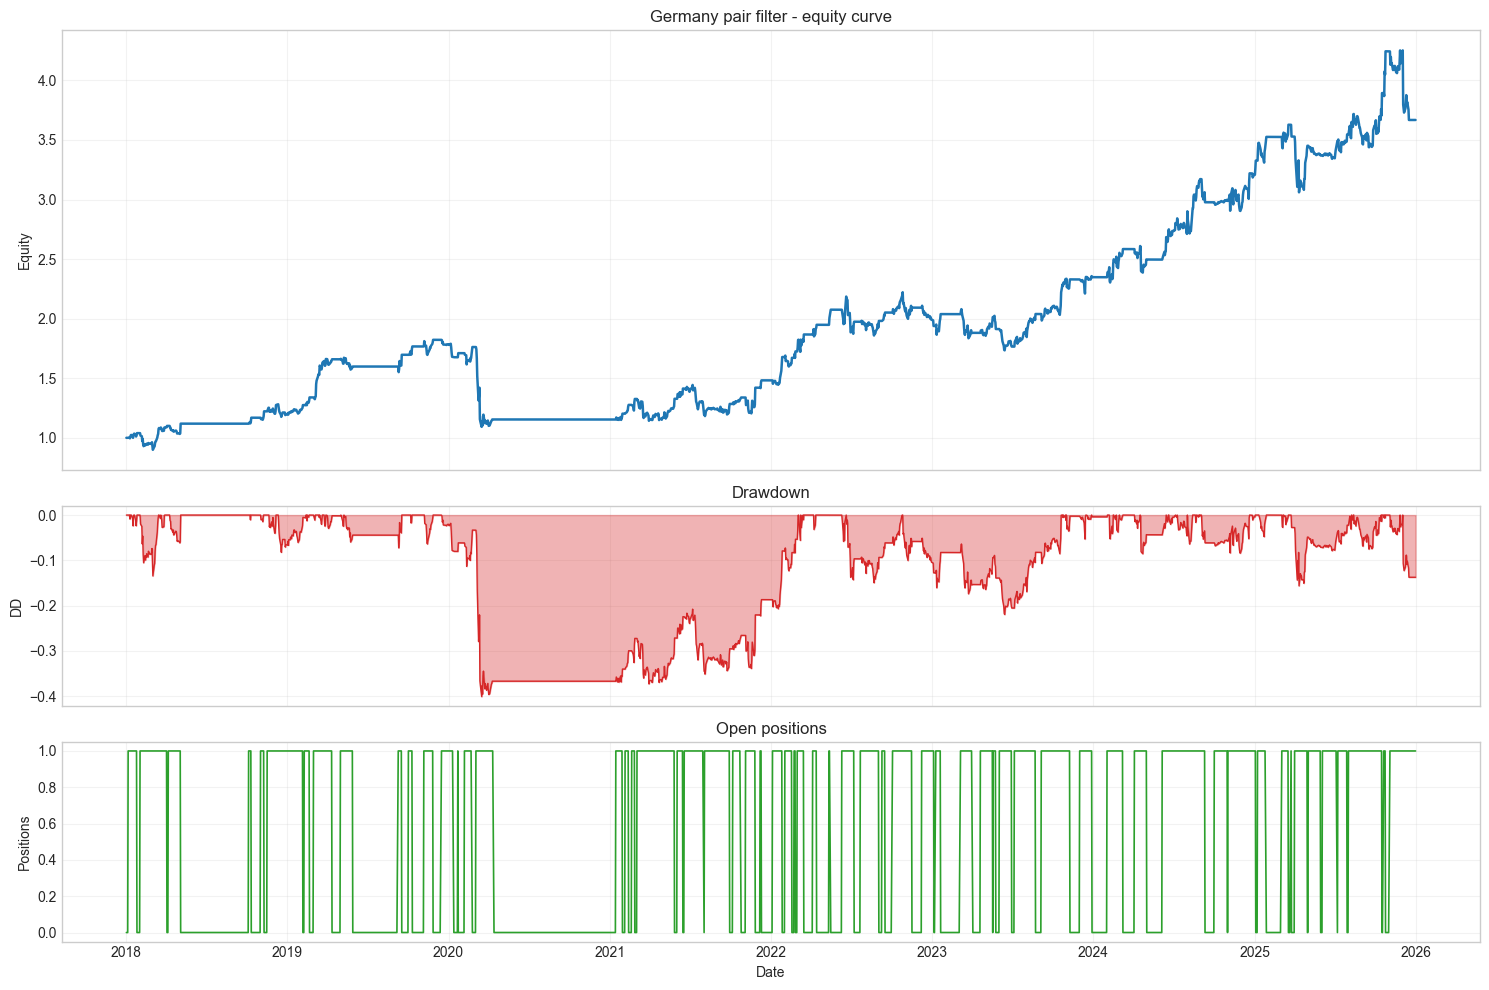

In [9]:
eq = equity.copy()
eq['datetime'] = pd.to_datetime(eq['datetime'], errors='coerce')
eq['equity'] = pd.to_numeric(eq['equity'], errors='coerce')
eq['n_open_positions'] = pd.to_numeric(eq.get('n_open_positions'), errors='coerce')
eq = eq.dropna(subset=['datetime', 'equity']).sort_values('datetime')
eq['drawdown'] = eq['equity'] / eq['equity'].cummax() - 1.0

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [2.2, 1, 1]})

axes[0].plot(eq['datetime'], eq['equity'], color='#1f77b4', linewidth=1.8)
axes[0].set_title('Germany pair filter - equity curve')
axes[0].set_ylabel('Equity')

axes[1].fill_between(eq['datetime'], eq['drawdown'], 0, color='#d62728', alpha=0.35)
axes[1].plot(eq['datetime'], eq['drawdown'], color='#d62728', linewidth=1.0)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('DD')

axes[2].plot(eq['datetime'], eq['n_open_positions'], color='#2ca02c', linewidth=1.2)
axes[2].set_title('Open positions')
axes[2].set_ylabel('Positions')
axes[2].set_xlabel('Date')

for ax in axes:
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


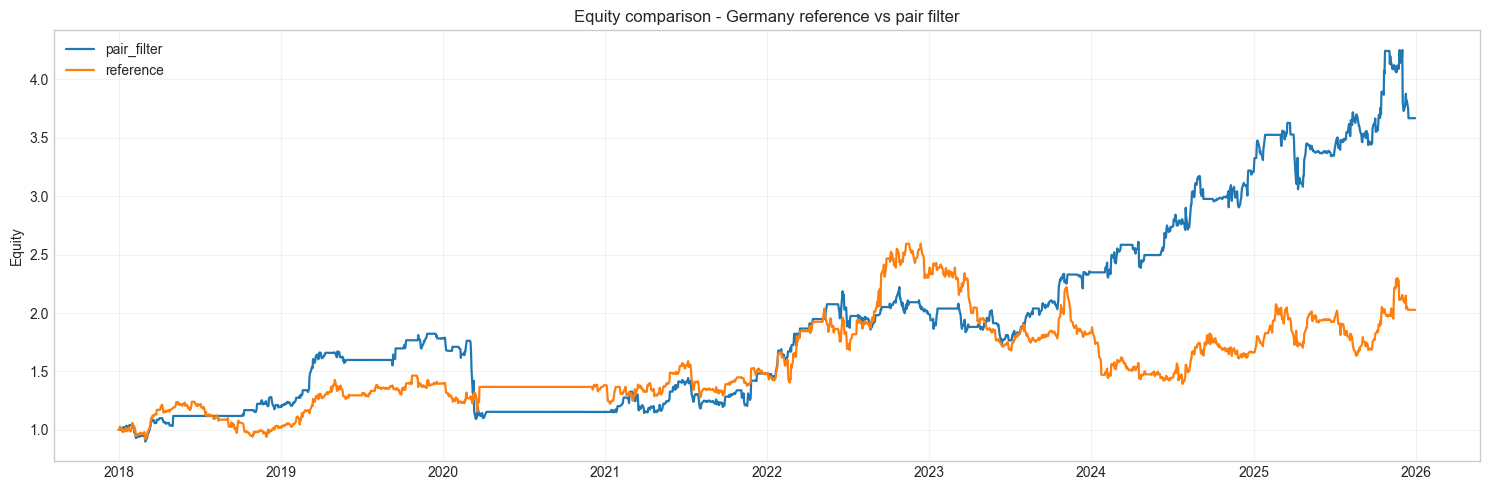

In [10]:
if RUN_REFERENCE_COMPARISON:
    fig, ax = plt.subplots(figsize=(15, 5))
    for label, run in runs.items():
        e = run['result']['equity'].copy()
        e['datetime'] = pd.to_datetime(e['datetime'], errors='coerce')
        e['equity'] = pd.to_numeric(e['equity'], errors='coerce')
        e = e.dropna(subset=['datetime', 'equity']).sort_values('datetime')
        ax.plot(e['datetime'], e['equity'], linewidth=1.6, label=label)
    ax.set_title('Equity comparison - Germany reference vs pair filter')
    ax.set_ylabel('Equity')
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


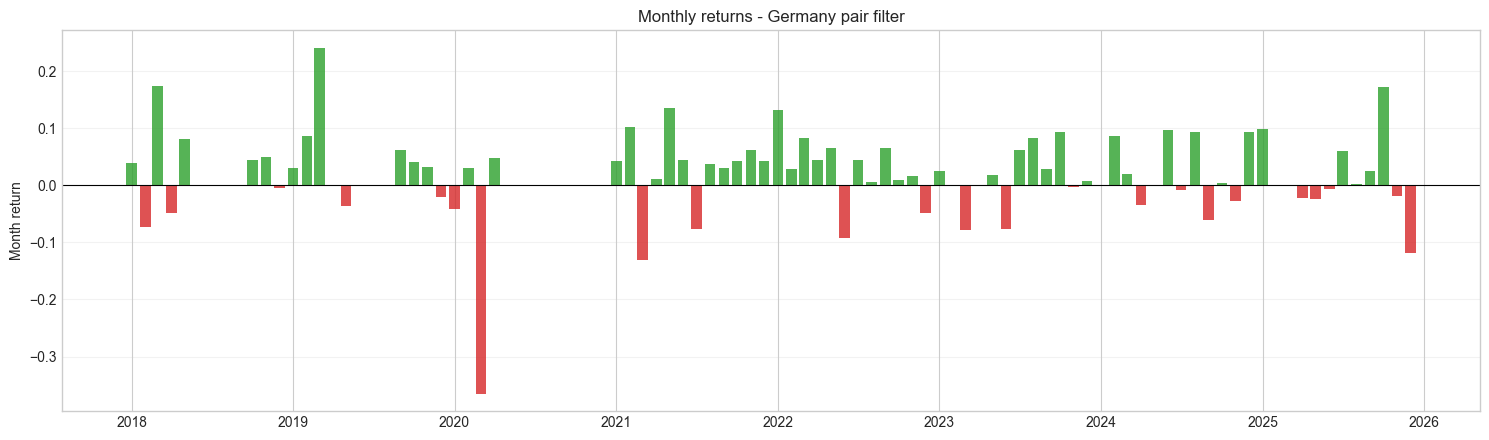

,trade_month,month_return,avg_open_positions,max_open_positions
72,2024-01,0.000000,0.000000,0
73,2024-02,0.087293,1.000000,1
74,2024-03,0.019539,0.238095,1
75,2024-04,-0.033828,0.909091,1
76,2024-05,0.000000,0.000000,0
77,2024-06,0.096281,0.900000,1
78,2024-07,-0.008870,1.000000,1
79,2024-08,0.093191,1.000000,1
80,2024-09,-0.061111,0.285714,1
81,2024-10,0.004207,0.956522,1


In [11]:
m = monthly.copy()
if not m.empty:
    m['trade_month_dt'] = pd.to_datetime(m['trade_month'], format='%Y-%m', errors='coerce')
    m['month_return'] = pd.to_numeric(m['month_return'], errors='coerce')
    colors = np.where(m['month_return'] >= 0, '#2ca02c', '#d62728')

    fig, ax = plt.subplots(figsize=(15, 4.5))
    ax.bar(m['trade_month_dt'], m['month_return'], width=24, color=colors, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Monthly returns - Germany pair filter')
    ax.set_ylabel('Month return')
    ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

    display(m[['trade_month', 'month_return', 'avg_open_positions', 'max_open_positions']].tail(24))
else:
    print('No monthly returns available.')


## Graphes trades et exits

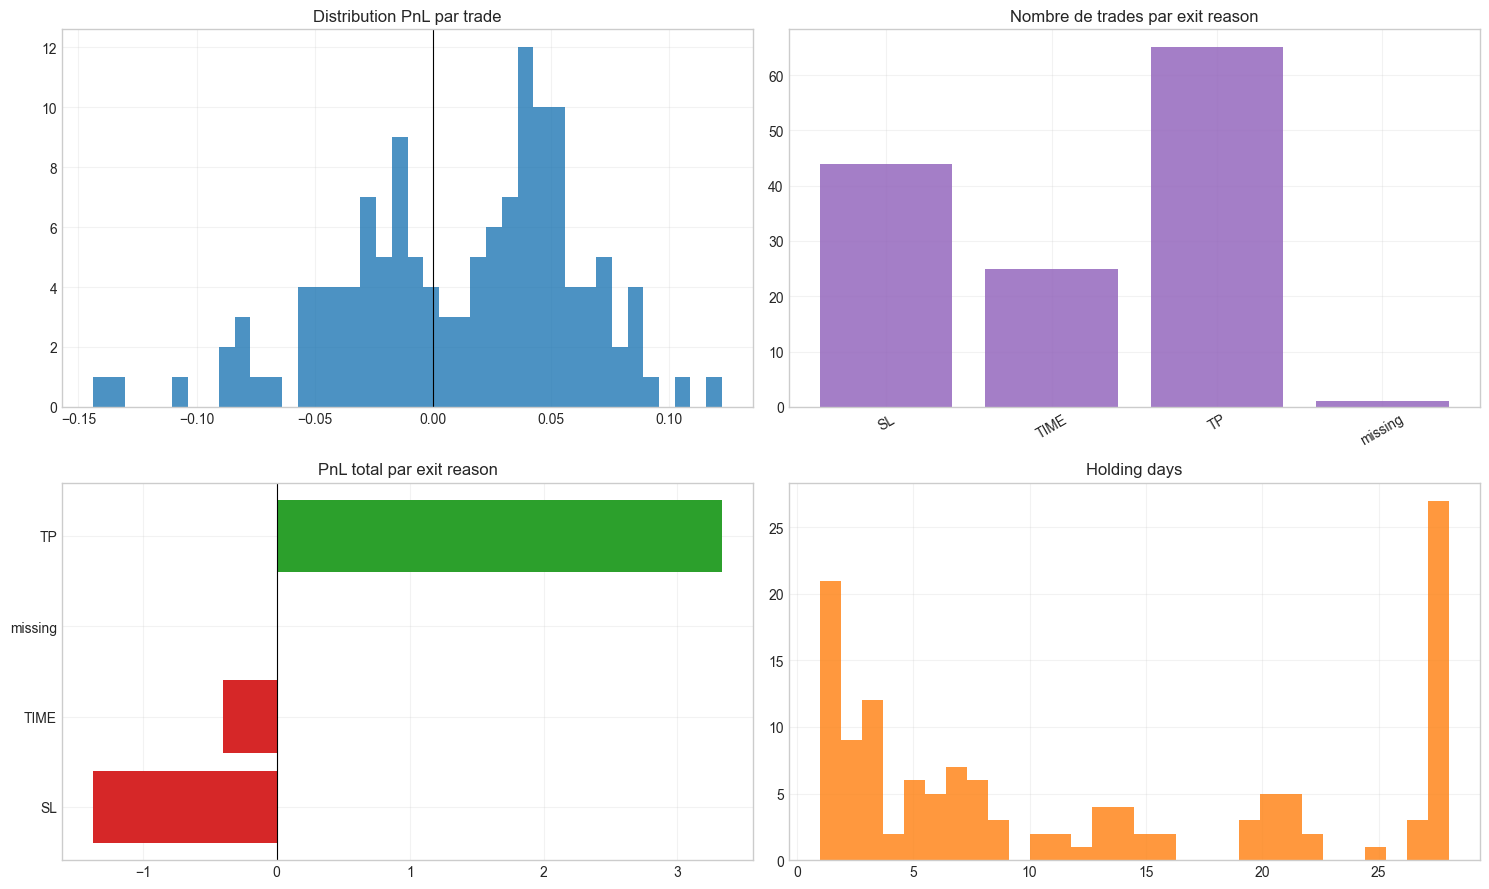

In [12]:
tr = enriched.copy()
tr['entry_datetime'] = pd.to_datetime(tr['entry_datetime'], errors='coerce')
tr['pnl'] = pd.to_numeric(tr['pnl'], errors='coerce')
tr['holding_days'] = pd.to_numeric(tr.get('holding_days'), errors='coerce')
closed = tr.dropna(subset=['pnl']).copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].hist(closed['pnl'], bins=40, color='#1f77b4', alpha=0.8)
axes[0, 0].axvline(0, color='black', linewidth=0.8)
axes[0, 0].set_title('Distribution PnL par trade')

exit_counts = tr['exit_reason_bucket'].fillna('missing').value_counts().sort_index()
axes[0, 1].bar(exit_counts.index.astype(str), exit_counts.values, color='#9467bd', alpha=0.85)
axes[0, 1].set_title('Nombre de trades par exit reason')
axes[0, 1].tick_params(axis='x', rotation=30)

exit_pnl = tr.groupby(tr['exit_reason_bucket'].fillna('missing'))['pnl'].sum().sort_values()
axes[1, 0].barh(exit_pnl.index.astype(str), exit_pnl.values, color=np.where(exit_pnl.values >= 0, '#2ca02c', '#d62728'))
axes[1, 0].axvline(0, color='black', linewidth=0.8)
axes[1, 0].set_title('PnL total par exit reason')

axes[1, 1].hist(tr['holding_days'].dropna(), bins=30, color='#ff7f0e', alpha=0.8)
axes[1, 1].set_title('Holding days')

for ax in axes.ravel():
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


## Analyse par segment

Change `SEGMENT_COL` pour explorer d'autres axes : `market_regime`, `stress_bucket`, `corr_type`, `beta_stability_bucket`, `abs_z_entry_quintile`, `z_speed_ewma_quintile`, `exit_reason_bucket`, etc.

D:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal\utils\edge_decomposition.py:386: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,segment_type,config_name,segment_value,nb_trades,win_rate,avg_pnl,median_pnl,total_pnl,avg_holding_days,median_holding_days,avg_mae,avg_mfe,tp_rate,sl_rate,timeout_rate,expectancy,profit_factor,trade_sharpe_like,contribution_to_total_pnl,contribution_to_total_trades
1,corr_type,pair_filter_corr_abs_le_0p75,medium_corr,90.0,0.600000,0.013308,0.022766,1.197710,12.733333,10.0,-0.023993,0.031452,0.477778,0.333333,0.188889,0.013308,1.946463,0.285136,0.769567,0.666667
0,corr_type,pair_filter_corr_abs_le_0p75,low_corr,45.0,0.590909,0.008151,0.014079,0.358633,11.659091,7.0,-0.027786,0.035627,0.488889,0.311111,0.177778,0.008151,1.431662,0.145077,0.230433,0.333333


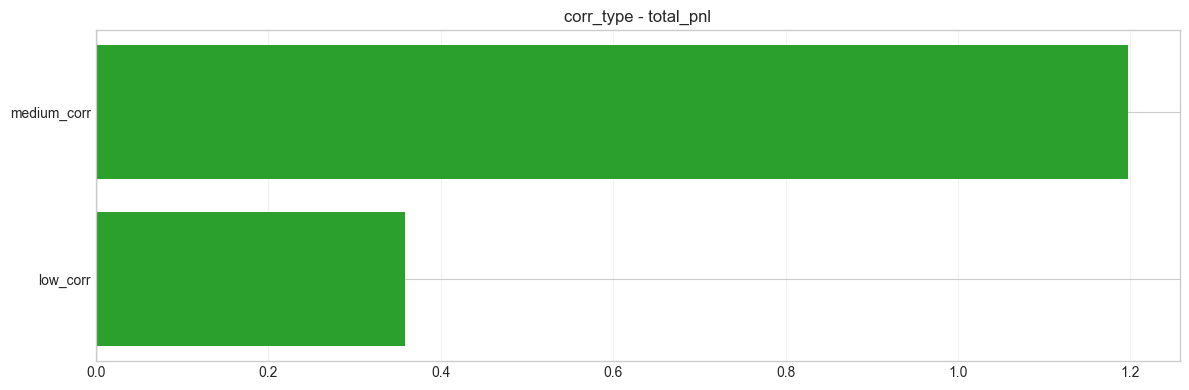

In [13]:
def show_segment(segment_col: str, min_trades: int = 3, sort_by: str = 'total_pnl') -> pd.DataFrame:
    if segment_col not in enriched.columns:
        raise KeyError(f'{segment_col} is not in enriched trades columns.')

    summary = summarize_edge_by_segment(enriched, (segment_col,))
    if summary.empty:
        print('No segment summary available.')
        return summary

    summary = summary[pd.to_numeric(summary['nb_trades'], errors='coerce') >= min_trades].copy()
    summary = summary.sort_values(sort_by, ascending=False)
    display(summary)

    plot_df = summary.sort_values(sort_by, ascending=True).tail(20)
    fig, ax = plt.subplots(figsize=(12, max(4, 0.42 * len(plot_df))))
    values = pd.to_numeric(plot_df[sort_by], errors='coerce')
    ax.barh(plot_df['segment_value'].astype(str), values, color=np.where(values >= 0, '#2ca02c', '#d62728'))
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{segment_col} - {sort_by}')
    ax.grid(True, axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()
    return summary


SEGMENT_COL = 'corr_type'
segment_summary = show_segment(SEGMENT_COL, min_trades=3, sort_by='total_pnl')


In [14]:
for col in ['market_regime', 'stress_bucket', 'trending_bucket', 'corr_type', 'pair_quality_bucket', 'beta_stability_bucket', 'abs_z_entry_quintile', 'z_speed_ewma_quintile', 'exit_reason_bucket']:
    if col in enriched.columns:
        display(Markdown(f'### {col}'))
        display(summarize_edge_by_segment(enriched, (col,)).sort_values('total_pnl', ascending=False))


### market_regime

D:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal\utils\edge_decomposition.py:386: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,segment_type,config_name,segment_value,nb_trades,win_rate,avg_pnl,median_pnl,total_pnl,avg_holding_days,median_holding_days,avg_mae,avg_mfe,tp_rate,sl_rate,timeout_rate,expectancy,profit_factor,trade_sharpe_like,contribution_to_total_pnl,contribution_to_total_trades
0,market_regime,pair_filter_corr_abs_le_0p75,neutral,62.0,0.688525,0.013448,0.026514,0.820333,15.180328,15.0,-0.025868,0.031172,0.548387,0.193548,0.241935,0.013448,1.962246,0.292867,0.527090,0.459259
1,market_regime,pair_filter_corr_abs_le_0p75,stress,19.0,0.736842,0.027858,0.035062,0.529300,10.894737,8.0,-0.018971,0.040380,0.736842,0.210526,0.052632,0.027858,4.164246,0.630513,0.340092,0.140741
3,market_regime,pair_filter_corr_abs_le_0p75,trending,19.0,0.684211,0.025891,0.040368,0.491924,12.789474,9.0,-0.022460,0.039023,0.578947,0.263158,0.157895,0.025891,3.699040,0.591780,0.316077,0.140741
2,market_regime,pair_filter_corr_abs_le_0p75,stress_trending,35.0,0.314286,-0.008149,-0.014958,-0.285215,8.085714,3.0,-0.029053,0.028233,0.171429,0.657143,0.171429,-0.008149,0.681049,-0.142291,-0.183259,0.259259


### stress_bucket

D:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal\utils\edge_decomposition.py:386: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



...

D:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal\utils\edge_decomposition.py:386: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,segment_type,config_name,segment_value,nb_trades,win_rate,avg_pnl,median_pnl,total_pnl,avg_holding_days,median_holding_days,avg_mae,avg_mfe,tp_rate,sl_rate,timeout_rate,expectancy,profit_factor,trade_sharpe_like,contribution_to_total_pnl,contribution_to_total_trades
0,z_speed_ewma_quintile,pair_filter_corr_abs_le_0p75,zspeed_ewma_q1,27.0,0.730769,0.019349,0.028805,0.503084,17.307692,18.5,-0.025753,0.035898,0.481481,0.148148,0.333333,0.019349,2.750922,0.395746,0.323247,0.2
3,z_speed_ewma_quintile,pair_filter_corr_abs_le_0p75,zspeed_ewma_q4,27.0,0.592593,0.018615,0.022852,0.502599,9.074074,6.0,-0.015055,0.033065,0.481481,0.407407,0.111111,0.018615,3.259829,0.500624,0.322936,0.2
4,z_speed_ewma_quintile,pair_filter_corr_abs_le_0p75,zspeed_ewma_q5,27.0,0.481481,0.015014,-0.002392,0.405390,7.592593,5.0,-0.016372,0.031623,0.444444,0.555556,0.000000,0.015014,2.060872,0.289856,0.260476,0.2
1,z_speed_ewma_quintile,pair_filter_corr_abs_le_0p75,zspeed_ewma_q2,27.0,0.666667,0.009964,0.028436,0.269036,15.296296,15.0,-0.034265,0.036233,0.555556,0.185185,0.259259,0.009964,1.545075,0.185758,0.172864,0.2
2,z_speed_ewma_quintile,pair_filter_corr_abs_le_0p75,zspeed_ewma_q3,27.0,0.518519,-0.004584,0.001859,-0.123765,12.814815,8.0,-0.034768,0.027411,0.444444,0.333333,0.222222,-0.004584,0.825889,-0.082770,-0.079523,0.2


### exit_reason_bucket

D:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal\utils\edge_decomposition.py:386: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,segment_type,config_name,segment_value,nb_trades,win_rate,avg_pnl,median_pnl,total_pnl,avg_holding_days,median_holding_days,avg_mae,avg_mfe,tp_rate,sl_rate,timeout_rate,expectancy,profit_factor,trade_sharpe_like,contribution_to_total_pnl,contribution_to_total_trades
2,exit_reason_bucket,pair_filter_corr_abs_le_0p75,TP,65.0,1.000000,0.051320,0.045653,3.335779,12.938462,12.0,-0.013206,0.051755,1.0,0.0,0.0,0.051320,inf,2.365184,2.143345,0.481481
1,exit_reason_bucket,pair_filter_corr_abs_le_0p75,TIME,25.0,0.440000,-0.016216,-0.014612,-0.405389,28.000000,28.0,-0.045776,0.026399,0.0,0.0,1.0,-0.016216,0.421802,-0.349688,-0.260475,0.185185
0,exit_reason_bucket,pair_filter_corr_abs_le_0p75,SL,44.0,0.090909,-0.031228,-0.024736,-1.374047,2.681818,2.0,-0.031344,0.008505,0.0,1.0,0.0,-0.031228,0.015128,-0.954336,-0.882869,0.325926
3,exit_reason_bucket,pair_filter_corr_abs_le_0p75,missing,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.007407


## Sauvegarde optionnelle des outputs du notebook

In [15]:
if SAVE_OUTPUTS:
    run_name = f'{CONFIG_NAME}_{pd.Timestamp(START).strftime("%Y%m%d")}_{pd.Timestamp(END).strftime("%Y%m%d")}'
    out_dir = OUTPUT_DIR / run_name
    out_dir.mkdir(parents=True, exist_ok=True)

    equity.to_csv(out_dir / 'equity.csv', index=False)
    trades.to_csv(out_dir / 'trades.csv', index=False)
    enriched.to_csv(out_dir / 'trades_enriched.csv', index=False)
    monthly.to_csv(out_dir / 'monthly_returns.csv', index=False)
    stats.to_csv(out_dir / 'portfolio_stats.csv', index=False)
    trade_level.to_csv(out_dir / 'trade_level_summary.csv', index=False)
    concentration.to_csv(out_dir / 'concentration_summary.csv', index=False)
    pair_level.to_csv(out_dir / 'pair_level_summary.csv', index=False)
    pd.DataFrame([filter_scan_diag]).to_csv(out_dir / 'filter_scan_diagnostics.csv', index=False)

    if RUN_REFERENCE_COMPARISON:
        portfolio_comparison.to_csv(out_dir / 'portfolio_comparison.csv', index=False)
        trade_comparison.to_csv(out_dir / 'trade_comparison.csv', index=False)
        concentration_comparison.to_csv(out_dir / 'concentration_comparison.csv', index=False)

    manifest = {
        'country': COUNTRY,
        'config_name': CONFIG_NAME,
        'start': START,
        'end': END,
        'reference': reference.__dict__,
        'filter': {
            'definition': 'exclude scan rows with abs(6m_corr) > corr_abs_max',
            'corr_abs_max': CORR_ABS_MAX,
        },
        'thresholds': {
            'abs_z_extreme_min': thresholds.abs_z_extreme_min,
            'zspeed_ewma_extreme_min': thresholds.zspeed_ewma_extreme_min,
            'beta_stability_degraded_min': thresholds.beta_stability_degraded_min,
        },
        'strategy_params': vars(params),
    }
    (out_dir / 'manifest.json').write_text(json.dumps(manifest, indent=2, default=str), encoding='utf-8')
    print(f'Saved notebook outputs to: {out_dir}')
else:
    print('SAVE_OUTPUTS=False, nothing saved.')


Saved notebook outputs to: D:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal\data\experiments\notebook_germany_pair_filter_strategy_run\pair_filter_corr_abs_le_0p75_20180101_20251231
